# Modelo de Clasificación con Árboles de Decisión
## Predicción de resultados de fútbol

**Variable objetivo:** `resultado_real`

Clases:
- **S** = victoria local
- **H** = empate
- **A** = victoria visitante

El objetivo es clasificar el resultado de un partido utilizando información disponible antes de conocer el marcador final.

## 1. Definición del problema y variables

Se utiliza `resultado_real` porque representa directamente el resultado que se desea predecir.

Como variables independientes se consideran votos previos de los participantes y estadísticas deportivas previas del equipo: votos local/empate/visitante, total de participantes, ranking, partidos jugados, puntos y goles anotados/recibidos. También se utiliza `Weekday` si está disponible para demostrar codificación de variables categóricas.

No se utilizan variables que revelen directamente el marcador final como entrada del modelo para evitar fuga de información.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
    roc_curve, auc
)

pd.set_option("display.max_columns", None)

## 2. Carga de los datos

In [4]:
ruta = "/home/fabian/Escritorio/Grupo_Patitogit/Data/raw/predicciones_personas.csv"
datos = pd.read_csv(ruta)

print("Dimensiones:", datos.shape)
display(datos.head())

Dimensiones: (11417, 65)


,Votes_for_Home,Votes_for_Draw,Votes_for_Away,Weekday,Day,Month,Year,Hour,Minute,Total_Bettors,Bet_Perc_on_Home,Bet_Perc_on_Draw,Bet_Perc_on_Away,Team_1,Team_2,League_Rank_1,League_Rank_2,Total_teams,Games_played_1,Games_played_2,Points_1,Points_2,Max_points,Min_points,Won_1,Draw_1,Lost_1,Won_2,Draw_2,Lost_2,Goals_Scored_1,Goals_Scored_2,Goals_Rec_1,Goal_Rec_2,Goals_Diff_1,Goals_Diff_2,Team_1_Found,Team_2_Found,Rank_1,Rank_2,Win_Perc_1,Win_Perc_2,League_type_country,Draw_Perc_1,Draw_Perc_2,Large_Diff_win,Won_out_of_6,Avrage_FT_Goal,Average_HT_Goal,Number_of_H2H_matches,Jumps,Odds_Home,Odds_Draw,Odds_Away,Country_1,Country_2,Detail_H2H,Indices_home,Indices_draw,Indices_away,Results_1,Results_2,resultado_real,prediccion_personas,acierto_personas
0,18,14,19,Thu,3,1,2019,21,0,64512,34,12,52,manchester c,liverpool,3.0,1.0,20.0,20.0,20.0,47.0,54.0,54.0,10.0,15.0,2.0,3.0,17.0,3.0,0.0,54.0,48.0,16.0,8.0,38.0,40.0,manchester city,liverpool,2.0,1.0,88.0,95.0,england,7.0,7.0,0.0,4.0,3.50,1.33,37.0,1.0,2.0,3.9,3.5,england,england,3/A/D/0/0_6/H/L/1/2_9/H/L/1/2_10/A/L/0/3_12/A/...,9_10_13_19_21_52_44_46_24_77_82_87_88_89_90_10...,6_14_50_51_25_38_43_78_85_86_92_93_94_104,11_12_15_16_27_30_35_37_39_54_81_84_96_99_102_...,2,1,S,A,False
1,3,1,45,Wed,2,1,2019,21,0,25872,10,8,78,newcastle,manchester u,15.0,6.0,20.0,20.0,20.0,18.0,35.0,54.0,10.0,4.0,6.0,10.0,10.0,5.0,5.0,15.0,41.0,27.0,32.0,-12.0,9.0,newcastle united,manchester united,15.0,6.0,30.0,49.0,england,30.0,25.0,0.0,0.0,3.00,1.33,28.0,1.0,5.7,4.1,1.6,england,england,3/A/L/2/3_11/H/W/1/0_14/A/L/1/4_37/H/D/3/3_41/...,21_42_44,104,48_6_9_10_11_12_14_15_16_19_51_52_53_26_27_28_...,0,2,A,A,True
2,5,1,42,Sat,12,1,2019,16,0,22624,11,10,76,brighton,liverpool,13.0,1.0,20.0,21.0,21.0,26.0,54.0,54.0,10.0,7.0,5.0,9.0,17.0,3.0,1.0,24.0,49.0,29.0,10.0,-5.0,39.0,brighton and hove albion,liverpool,13.0,1.0,37.0,97.0,england,18.0,6.0,0.0,5.0,4.20,1.80,5.0,5.0,11.0,6.0,1.3,england,england,5/A/L/0/1_9/A/L/0/4_14/H/L/1/5_84/A/L/1/6_90/H...,13_14_21_42_100,93,3_6_8_9_10_11_12_15_16_50_18_51_52_29_30_35_36...,0,1,A,A,True
3,46,0,1,Sat,19,1,2019,16,0,22400,84,7,6,manchester united,brighton and hove albion,6.0,13.0,20.0,22.0,22.0,41.0,26.0,57.0,11.0,12.0,5.0,5.0,7.0,5.0,10.0,44.0,24.0,32.0,30.0,12.0,-6.0,manchester united,brighton and hove albion,6.0,13.0,55.0,30.0,england,30.0,18.0,0.0,0.0,2.25,1.25,4.0,1.0,1.3,5.7,12.0,england,england,6/A/L/2/3_9/A/L/0/1_11/H/W/2/0_15/H/W/1/0,2_3_6_9_10_11_12_13_14_16_50_18_19_21_52_26_27...,NaN,36,2,1,S,S,True
4,44,0,3,Sat,12,1,2019,18,30,16576,77,11,8,chelsea,newcastle,4.0,15.0,20.0,21.0,21.0,44.0,18.0,54.0,10.0,13.0,5.0,3.0,4.0,6.0,11.0,38.0,15.0,16.0,29.0,22.0,-14.0,chelsea,newcastle united,4.0,15.0,68.0,25.0,england,13.0,30.0,0.0,4.0,3.83,1.66,29.0,1.0,1.2,5.4,10.9,england,england,5/A/W/2/1_9/A/L/0/3_12/H/W/3/0_14/H/W/3/1_36/H...,6_8_10_11_12_14_15_16_50_18_51_21_52_27_29_35_...,NaN,30_77_100,2,1,S,S,True


### Revisión inicial

In [5]:
print("Columnas:")
print(datos.columns.tolist())

print("\nDistribución de resultado_real:")
print(datos["resultado_real"].value_counts(dropna=False))

print("\nNulos:")
nulos = datos.isna().sum()
print(nulos[nulos > 0].sort_values(ascending=False))

Columnas:
['Votes_for_Home', 'Votes_for_Draw', 'Votes_for_Away', 'Weekday', 'Day', 'Month', 'Year', 'Hour', 'Minute', 'Total_Bettors', 'Bet_Perc_on_Home', 'Bet_Perc_on_Draw', 'Bet_Perc_on_Away', 'Team_1', 'Team_2', 'League_Rank_1', 'League_Rank_2', 'Total_teams', 'Games_played_1', 'Games_played_2', 'Points_1', 'Points_2', 'Max_points', 'Min_points', 'Won_1', 'Draw_1', 'Lost_1', 'Won_2', 'Draw_2', 'Lost_2', 'Goals_Scored_1', 'Goals_Scored_2', 'Goals_Rec_1', 'Goal_Rec_2', 'Goals_Diff_1', 'Goals_Diff_2', 'Team_1_Found', 'Team_2_Found', 'Rank_1', 'Rank_2', 'Win_Perc_1', 'Win_Perc_2', 'League_type_country', 'Draw_Perc_1', 'Draw_Perc_2', 'Large_Diff_win', 'Won_out_of_6', 'Avrage_FT_Goal', 'Average_HT_Goal', 'Number_of_H2H_matches', 'Jumps', 'Odds_Home', 'Odds_Draw', 'Odds_Away', 'Country_1', 'Country_2', 'Detail_H2H', 'Indices_home', 'Indices_draw', 'Indices_away', 'Results_1', 'Results_2', 'resultado_real', 'prediccion_personas', 'acierto_personas']

Distribución de resultado_real:
resultad

## 3. Selección de variables independientes

El código comprueba cuáles variables existen realmente en el archivo y trabaja únicamente con ellas.

In [6]:
numericas_candidatas = [
    "Votes_for_Home", "Votes_for_Draw", "Votes_for_Away",
    "Total_Bettors",
    "League_Rank_1", "League_Rank_2",
    "Games_played_1", "Games_played_2",
    "Points_1", "Points_2",
    "Goals_Scored_1", "Goals_Scored_2",
    "Goals_Rec_1", "Goal_Rec_2"
]

categoricas_candidatas = ["Weekday"]

numericas = [x for x in numericas_candidatas if x in datos.columns]
categoricas = [x for x in categoricas_candidatas if x in datos.columns]
variables = numericas + categoricas

print("Numéricas:", numericas)
print("Categóricas:", categoricas)
print("Total variables:", len(variables))

Numéricas: ['Votes_for_Home', 'Votes_for_Draw', 'Votes_for_Away', 'Total_Bettors', 'League_Rank_1', 'League_Rank_2', 'Games_played_1', 'Games_played_2', 'Points_1', 'Points_2', 'Goals_Scored_1', 'Goals_Scored_2', 'Goals_Rec_1', 'Goal_Rec_2']
Categóricas: ['Weekday']
Total variables: 15


## 4. Preparación de datos

- Los nulos numéricos se completan con la **mediana**.
- Los nulos categóricos se completan con la **moda**.
- Las variables categóricas se codifican con **One-Hot Encoding**.
- Todo el proceso se integra en un `Pipeline` reproducible.

In [7]:
datos_modelo = datos.dropna(subset=["resultado_real"]).copy()

X = datos_modelo[variables]
y = datos_modelo["resultado_real"]

num_pipe = Pipeline([
    ("imputador", SimpleImputer(strategy="median"))
])

transformadores = [
    ("numericas", num_pipe, numericas)
]

if categoricas:
    cat_pipe = Pipeline([
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])
    transformadores.append(("categoricas", cat_pipe, categoricas))

preprocesador = ColumnTransformer(transformadores)

print("X:", X.shape)
print("y:", y.shape)

X: (11417, 15)
y: (11417,)


## 5. División en entrenamiento y prueba

Se utiliza 80% para entrenamiento y 20% para prueba. `stratify=y` conserva aproximadamente la proporción de S, H y A en ambos conjuntos.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (9133, 15)
Prueba: (2284, 15)


## 6. Árbol de Decisión inicial

In [9]:
modelo_inicial = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", DecisionTreeClassifier(random_state=42))
])

modelo_inicial.fit(X_train, y_train)
pred_inicial = modelo_inicial.predict(X_test)

print("Modelo inicial entrenado.")

Modelo inicial entrenado.


## 7. Evaluación del modelo inicial

In [10]:
def evaluar(y_real, y_pred, nombre):
    r = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(y_real, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_real, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_real, y_pred, average="weighted", zero_division=0)
    }
    print(nombre)
    for k, v in r.items():
        if k != "Modelo":
            print(f"{k}: {v:.4f} ({v*100:.2f}%)")
    return r

res_inicial = evaluar(y_test, pred_inicial, "Árbol inicial")

print("\nReporte por clase:")
print(classification_report(y_test, pred_inicial, zero_division=0))

Árbol inicial
Accuracy: 0.4137 (41.37%)
Precision: 0.4179 (41.79%)
Recall: 0.4137 (41.37%)
F1: 0.4155 (41.55%)

Reporte por clase:
              precision    recall  f1-score   support

           A       0.37      0.40      0.39       698
           H       0.24      0.24      0.24       522
           S       0.53      0.51      0.52      1064

    accuracy                           0.41      2284
   macro avg       0.38      0.38      0.38      2284
weighted avg       0.42      0.41      0.42      2284



### Matriz de confusión - modelo inicial

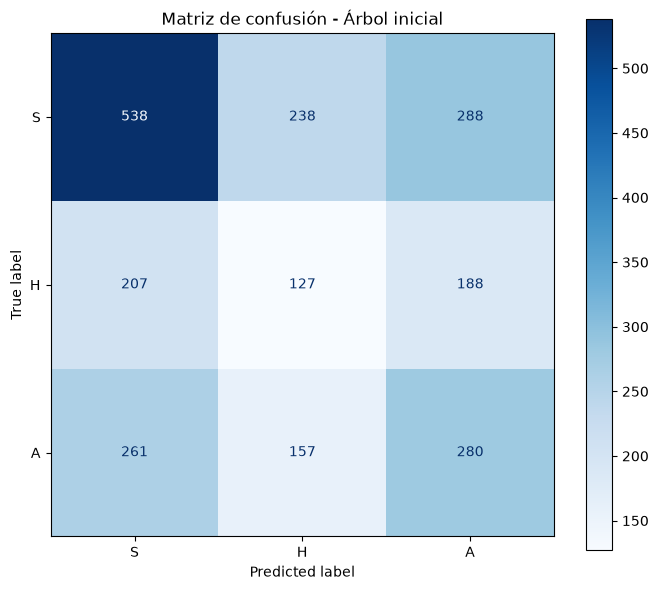

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_inicial,
    labels=["S","H","A"],
    cmap="Blues",
    values_format="d",
    ax=ax
)
plt.title("Matriz de confusión - Árbol inicial")
plt.tight_layout()
plt.show()

## 8. Ajuste de hiperparámetros

Se utiliza `GridSearchCV` con validación cruzada de 5 particiones y F1 ponderado como métrica de selección.

Se prueban:
- profundidad máxima,
- criterio de división,
- mínimo de muestras para dividir,
- mínimo de muestras por hoja.

In [12]:
modelo_busqueda = Pipeline([
    ("preprocesador", preprocesador),
    ("modelo", DecisionTreeClassifier(random_state=42))
])

param_grid = {
    "modelo__max_depth": [3, 5, 7, 10, None],
    "modelo__criterion": ["gini", "entropy"],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 5, 10]
}

busqueda = GridSearchCV(
    modelo_busqueda,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

busqueda.fit(X_train, y_train)

print("Mejores parámetros:")
print(busqueda.best_params_)
print("Mejor F1 de validación:", round(busqueda.best_score_, 4))

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Mejores parámetros:
{'modelo__criterion': 'gini', 'modelo__max_depth': 5, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 10}
Mejor F1 de validación: 0.4759


## 9. Evaluación del modelo optimizado

In [13]:
modelo_optimo = busqueda.best_estimator_
pred_optimo = modelo_optimo.predict(X_test)

res_optimo = evaluar(y_test, pred_optimo, "Árbol optimizado")

print("\nReporte por clase:")
print(classification_report(y_test, pred_optimo, zero_division=0))

Árbol optimizado
Accuracy: 0.5267 (52.67%)
Precision: 0.4493 (44.93%)
Recall: 0.5267 (52.67%)
F1: 0.4566 (45.66%)

Reporte por clase:
              precision    recall  f1-score   support

           A       0.47      0.50      0.49       698
           H       0.20      0.01      0.01       522
           S       0.55      0.80      0.66      1064

    accuracy                           0.53      2284
   macro avg       0.41      0.44      0.38      2284
weighted avg       0.45      0.53      0.46      2284



## 10. Comparación de métricas

,Accuracy,Precision,Recall,F1
Modelo,,,,
Árbol inicial,41.37,41.79,41.37,41.55
Árbol optimizado,52.67,44.93,52.67,45.66


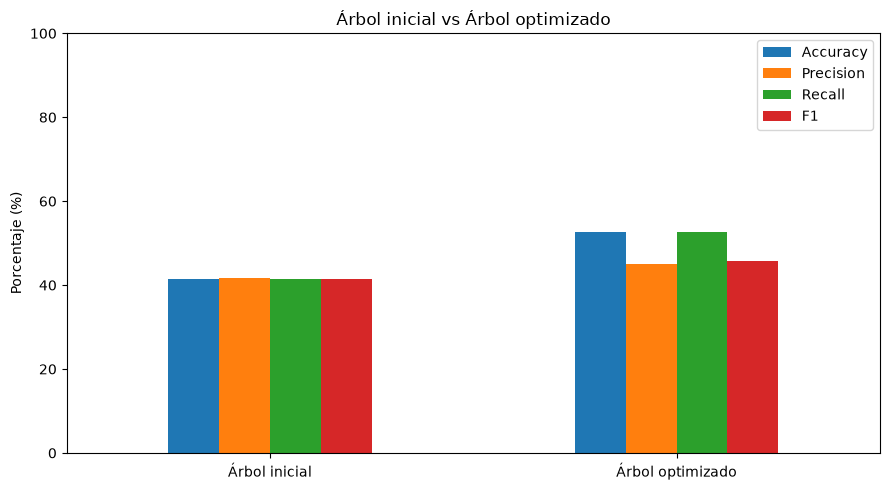

In [14]:
comparacion = pd.DataFrame([res_inicial, res_optimo]).set_index("Modelo")
display((comparacion * 100).round(2))

ax = (comparacion * 100).plot(kind="bar", figsize=(9,5))
plt.title("Árbol inicial vs Árbol optimizado")
plt.ylabel("Porcentaje (%)")
plt.xlabel("")
plt.ylim(0,100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Matriz de confusión - modelo optimizado

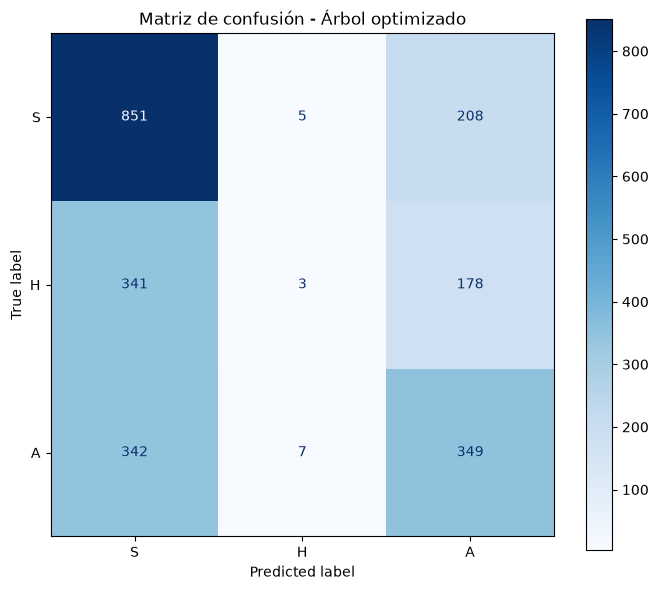

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_optimo,
    labels=["S","H","A"],
    cmap="Blues",
    values_format="d",
    ax=ax
)
plt.title("Matriz de confusión - Árbol optimizado")
plt.tight_layout()
plt.show()

## 12. Importancia de variables

La importancia indica cuánto utilizó el árbol cada característica para separar las clases. No debe interpretarse como causalidad.

,Variable,Importancia
2,numericas__Votes_for_Away,0.518809
0,numericas__Votes_for_Home,0.195224
4,numericas__League_Rank_1,0.109348
5,numericas__League_Rank_2,0.088178
3,numericas__Total_Bettors,0.022035
12,numericas__Goals_Rec_1,0.020563
11,numericas__Goals_Scored_2,0.020494
10,numericas__Goals_Scored_1,0.011455
8,numericas__Points_1,0.008033
13,numericas__Goal_Rec_2,0.005862


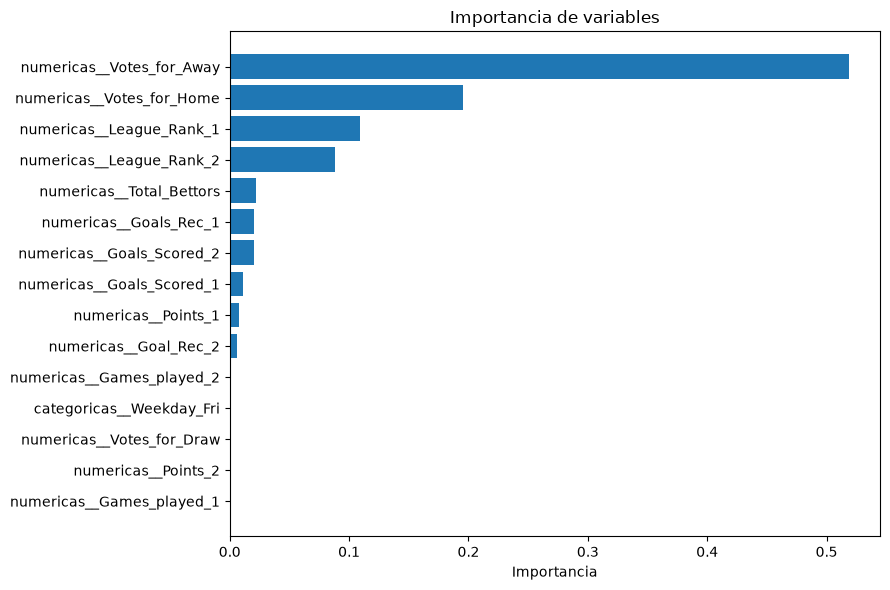

In [16]:
prep = modelo_optimo.named_steps["preprocesador"]
arbol = modelo_optimo.named_steps["modelo"]

nombres = prep.get_feature_names_out()
importancias = arbol.feature_importances_

tabla_importancia = pd.DataFrame({
    "Variable": nombres,
    "Importancia": importancias
}).sort_values("Importancia", ascending=False)

display(tabla_importancia.head(15))

top = tabla_importancia.head(15).sort_values("Importancia")

plt.figure(figsize=(9,6))
plt.barh(top["Variable"], top["Importancia"])
plt.title("Importancia de variables")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

## 13. Curva ROC multiclase

Se utiliza el enfoque One-vs-Rest. El AUC resume la capacidad del modelo para distinguir cada clase de las demás.

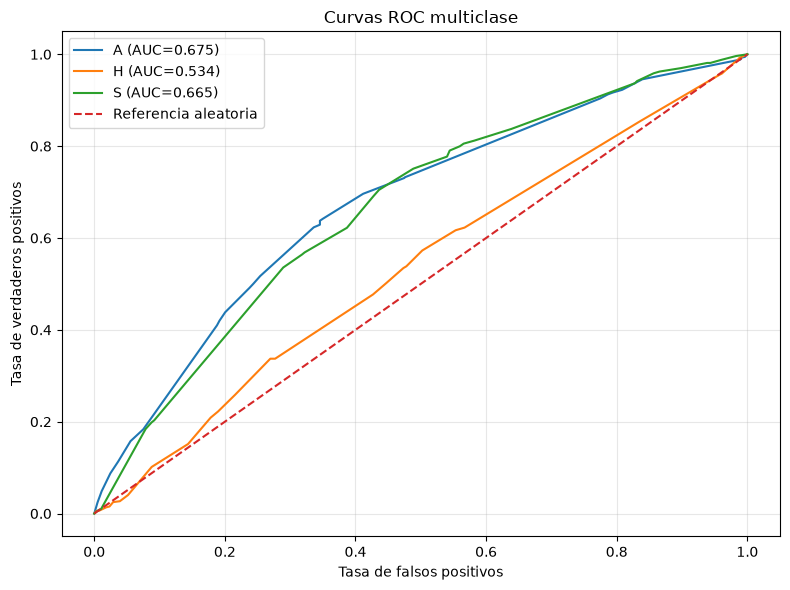

In [17]:
proba = modelo_optimo.predict_proba(X_test)
clases = list(arbol.classes_)
y_bin = label_binarize(y_test, classes=clases)

plt.figure(figsize=(8,6))

for i, clase in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
    auc_clase = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{clase} (AUC={auc_clase:.3f})")

plt.plot([0,1],[0,1], linestyle="--", label="Referencia aleatoria")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC multiclase")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Visualización del árbol

Se muestran solo los primeros tres niveles para que el gráfico sea legible. Esto no modifica el modelo entrenado.

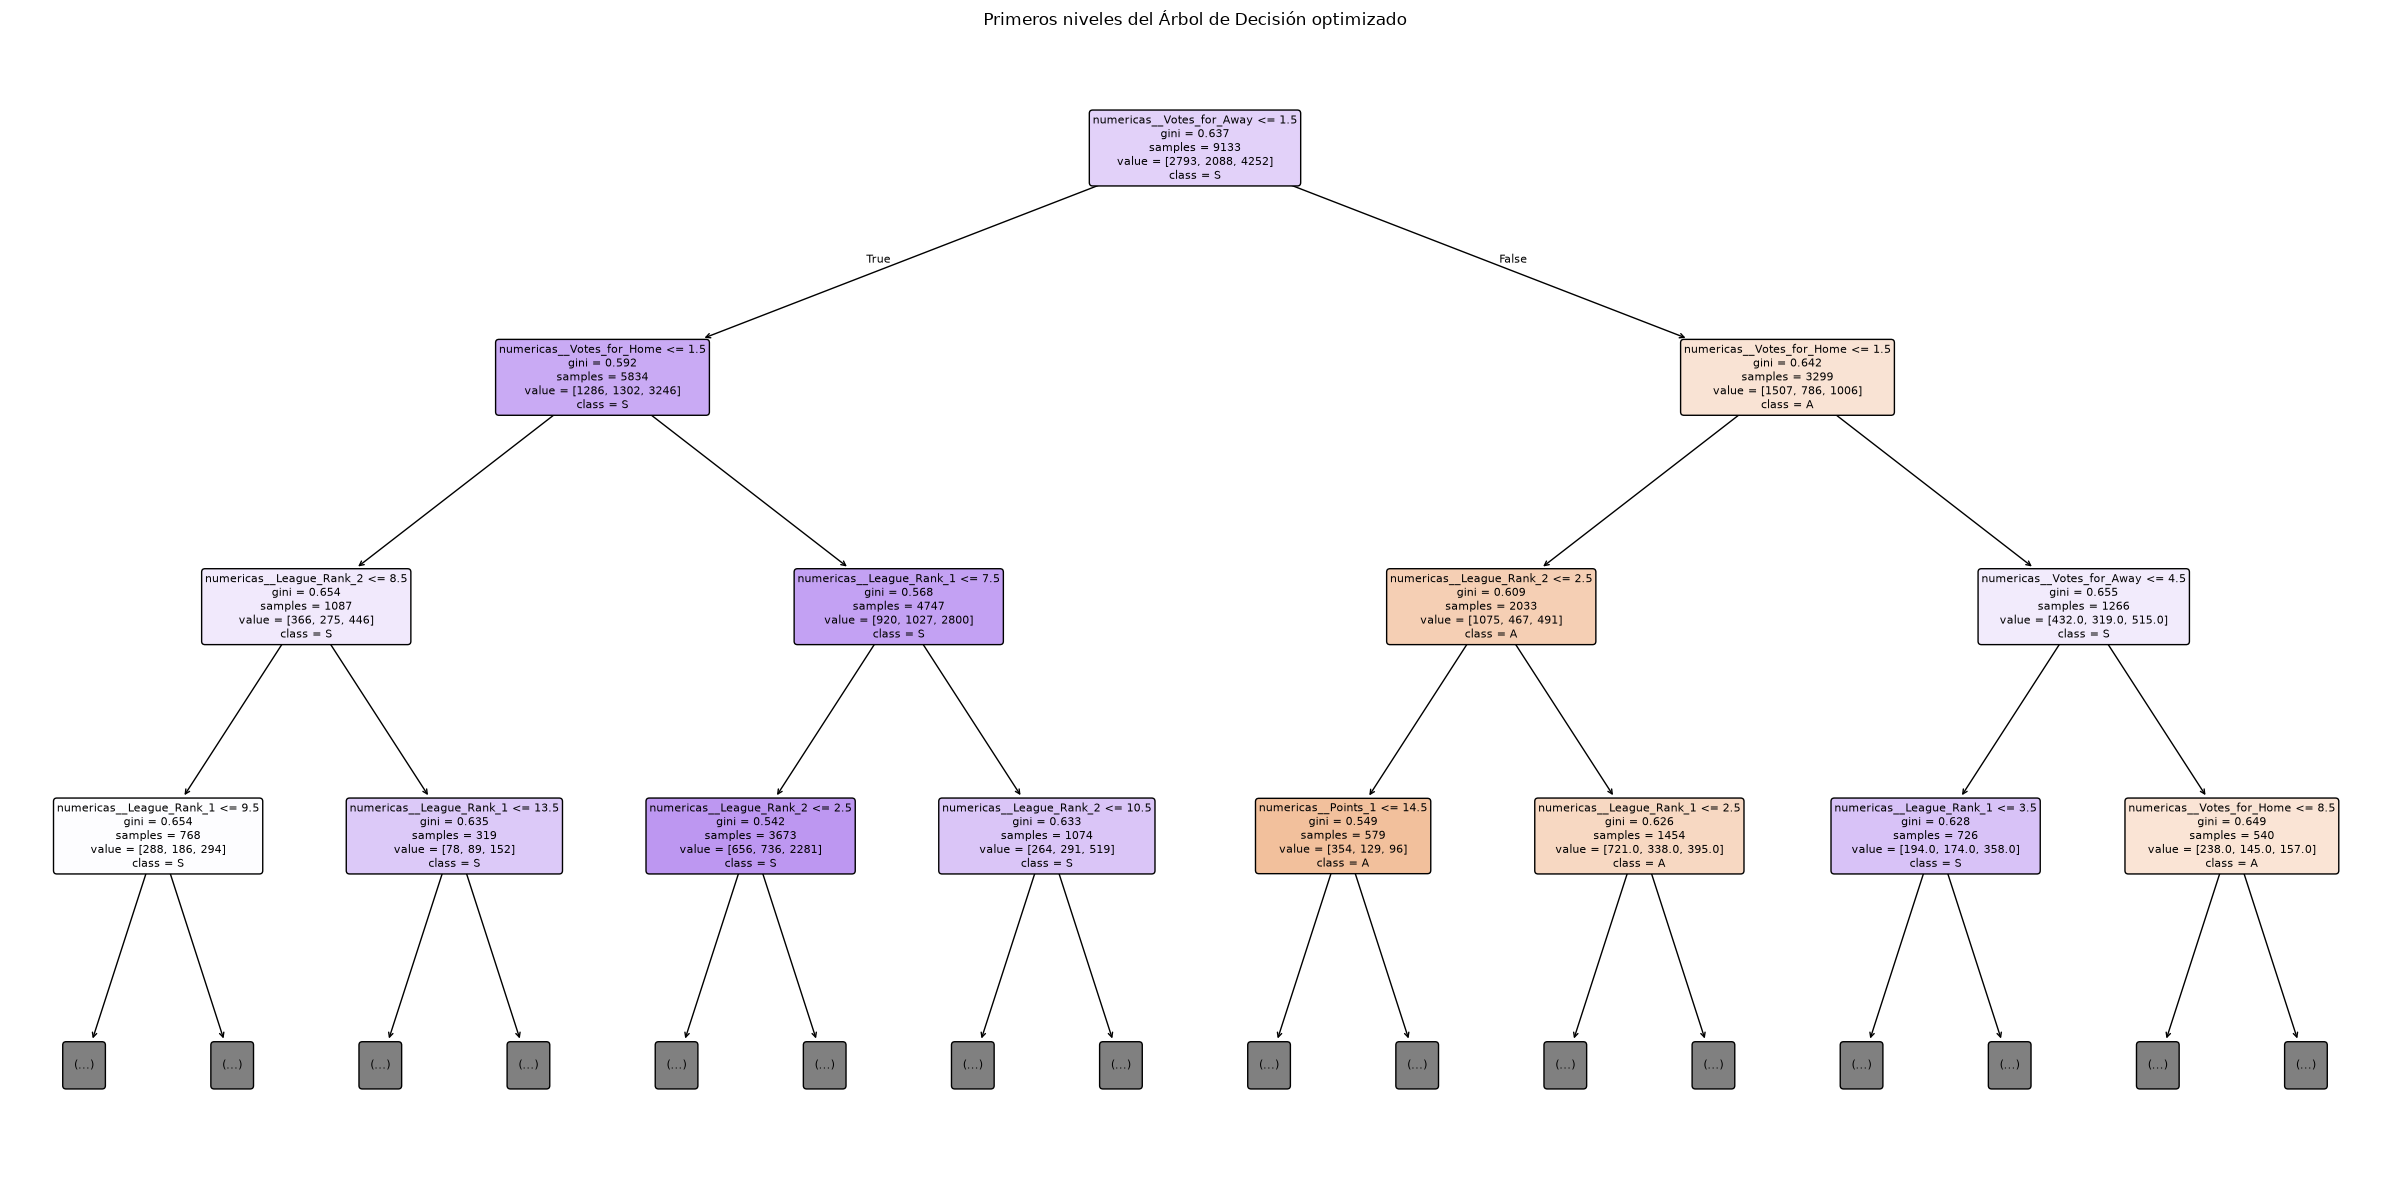

In [18]:
plt.figure(figsize=(24,12))
plot_tree(
    arbol,
    feature_names=nombres,
    class_names=[str(x) for x in arbol.classes_],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Primeros niveles del Árbol de Decisión optimizado")
plt.tight_layout()
plt.show()

## 15. Comparación con la predicción de las personas

Esta sección conecta el resultado técnico con el problema del proyecto comparando el modelo contra la predicción mayoritaria humana sobre el mismo conjunto de prueba.

,Método,Accuracy
0,Predicción de personas,0.524518
1,Árbol optimizado,0.526708


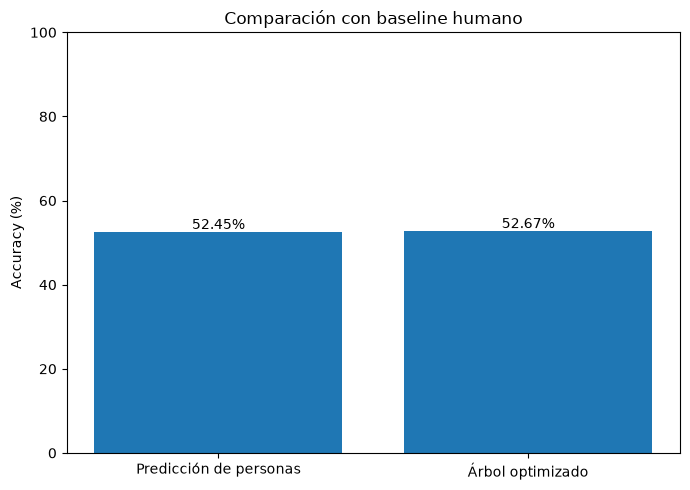

In [19]:
if "prediccion_personas" in datos_modelo.columns:
    pred_personas = datos_modelo.loc[X_test.index, "prediccion_personas"]

    acc_personas = accuracy_score(y_test, pred_personas)
    acc_arbol = accuracy_score(y_test, pred_optimo)

    negocio = pd.DataFrame({
        "Método": ["Predicción de personas", "Árbol optimizado"],
        "Accuracy": [acc_personas, acc_arbol]
    })

    display(negocio)

    plt.figure(figsize=(7,5))
    barras = plt.bar(negocio["Método"], negocio["Accuracy"]*100)
    plt.ylabel("Accuracy (%)")
    plt.title("Comparación con baseline humano")
    plt.ylim(0,100)

    for b, v in zip(barras, negocio["Accuracy"]*100):
        plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:.2f}%",
                 ha="center", va="bottom")

    plt.tight_layout()
    plt.show()
else:
    print("No existe la columna prediccion_personas; se omite esta comparación.")

## 16. Interpretación y conclusiones

- El Árbol de Decisión logró 52,67% de accuracy. (Accuracy indica qué porcentaje de partidos predijo correct)

- Superó ligeramente a la predicción humana de 52,45%.

- La mejora fue pequeña, por lo que todavía hay margen para mejorar el modelo.

- El árbol permite ver qué variables influyen más en la predicción.

- El modelo puede clasificar partidos en victoria local, empate o victoria visitante.


La conclusión final debe escribirse con los valores obtenidos al ejecutar el notebook. No se deben inventar porcentajes.

El Árbol de Decisión ofrece una ventaja importante para este proyecto: además de clasificar resultados, permite explicar de forma visual qué variables utiliza para tomar decisiones.



- VP = verdadero positivo → predijo bien esa clase.

- FP = falso positivo → dijo que era esa clase, pero no era.

- FN = falso negativo → era esa clase, pero no la detectó.

- VN = verdadero negativo → correctamente dijo que no era esa clase.

Y de ahí salen:

Accuracy=totalpredicciones / correctas​ 

Precision=VP+FPVP​ / Recall=VP+FNVP​ 

F1=2×Precision+Recall / Precision×Recall​

En cristiano:

La matriz de confusión muestra dónde acertó y dónde falló el modelo; Accuracy, Precision, Recall y F1 son números calculados a partir de esos resultados.